# IISE Energy Systems Division Data Competition 2026
## Power Outage Forecasting with Deep Kernel Learning

### Model: Deep Kernel Learning (DKL) — Standalone
A neural network feature extractor coupled with a Sparse Variational Gaussian Process (SVGP) that jointly handles:
- **Point predictions** (GP posterior mean) → s1, s2, s3
- **95% Prediction intervals** (GP posterior variance) → s4

### Architecture
```
Input (287 features: weather + outage lags + temporal)
    → Linear(287, 256) → ReLU → BatchNorm → Dropout(0.1)
    → Linear(256, 128) → ReLU → BatchNorm → Dropout(0.1)
    → Linear(128, 64)  → ReLU
    → Linear(64, 20)            ← learned embedding
    → SVGP (RBF-ARD kernel, 768 inducing points)
    → Gaussian likelihood       ← mean + variance
```

### Why DKL?
- The neural network learns nonlinear mappings from 109 weather variables + outage history to a compact representation
- The GP in the learned space provides **calibrated uncertainty** without separate quantile models
- SVGP with inducing points scales to ~175K training samples via mini-batch ELBO optimization
- End-to-end training: NN feature discovery and GP kernel learning are jointly optimized

### Hardware: Optimized for Mac Mini M4 (MPS acceleration)

## 0. Installation

In [23]:
# Run once, restart kernel if needed
!pip install numpy pandas xarray netCDF4 matplotlib tqdm
!pip install torch torchvision
!pip install gpytorch
!pip install scikit-learn shap

You should consider upgrading via the '/Users/aditya/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Aditya's_PhD_Drive_/IISE energy competition/iisenv/bin/python3 -m pip install --upgrade pip' command.
You should consider upgrading via the '/Users/aditya/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Aditya's_PhD_Drive_/IISE energy competition/iisenv/bin/python3 -m pip install --upgrade pip' command.
You should consider upgrading via the '/Users/aditya/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Aditya's_PhD_Drive_/IISE energy competition/iisenv/bin/python3 -m pip install --upgrade pip' command.
You should consider upgrading via the '/Users/aditya/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Aditya's_PhD_Drive_/IISE energy competition/iisenv/bin/python3 -m pip install --upgrade pip' command.


In [24]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import warnings
from tqdm.auto import tqdm
import time

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import gpytorch
from sklearn.metrics import f1_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# Force CPU — MPS crashes with GPyTorch float64 operations
DEVICE = torch.device("cpu")
print(f"Using CPU (GPyTorch MPS workaround)")

DATA_DIR = "data/"        # <--- CHANGE TO YOUR PATH
RESULTS_DIR = "results/"
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print(f"GPyTorch: {gpytorch.__version__}")


Using CPU (GPyTorch MPS workaround)
Device: cpu
PyTorch: 2.8.0
GPyTorch: 1.13


## 1. Data Loading

In [25]:
DATA_DIR = "/Users/aditya/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Aditya's_PhD_Drive_/IISE energy competition/dataset/data/"
RESULTS_DIR = "/Users/aditya/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Aditya's_PhD_Drive_/IISE energy competition/dataset/results/"

In [26]:
ds_train = xr.open_dataset(os.path.join(DATA_DIR, "train.nc"))

train_timestamps = pd.to_datetime(ds_train.timestamp.values)
locations = [str(loc) for loc in ds_train.location.values]
feature_names = list(ds_train.feature.values)

# Outage counts
outage_df = ds_train.out.transpose("timestamp", "location").to_pandas()
outage_df.index = train_timestamps
outage_df.columns = locations

# Tracked households
tracked_df = ds_train.tracked.transpose("timestamp", "location").to_pandas()
tracked_df.index = train_timestamps
tracked_df.columns = locations

# Weather — FAST vectorized (no Python loops)
print("Building weather DataFrame (vectorized)...")
weather_raw = ds_train.weather.transpose("timestamp", "location", "feature").values.astype(float)
n_t, n_l, n_f = weather_raw.shape
weather_flat = weather_raw.reshape(-1, n_f)
ts_col = np.repeat(train_timestamps, n_l)
loc_col = np.tile(locations, n_t)
weather_df = pd.DataFrame(weather_flat, columns=feature_names)
weather_df.insert(0, 'timestamp', ts_col)
weather_df.insert(1, 'location', loc_col)

print(f"Period: {train_timestamps.min()} to {train_timestamps.max()}")
print(f"Counties: {len(locations)}, Hours: {len(train_timestamps)}")
print(f"Weather features: {len(feature_names)}")
print(f"Weather DataFrame: {weather_df.shape}")


Building weather DataFrame (vectorized)...
Period: 2023-04-01 00:00:00 to 2023-06-30 00:00:00
Counties: 83, Hours: 2161
Weather features: 109
Weather DataFrame: (179363, 111)


=== Outage Distribution ===
Mean: 45.25, Std: 452.27
Min: 0, Max: 23346
Zeros: 70.5%
Nonzero median: 5.0


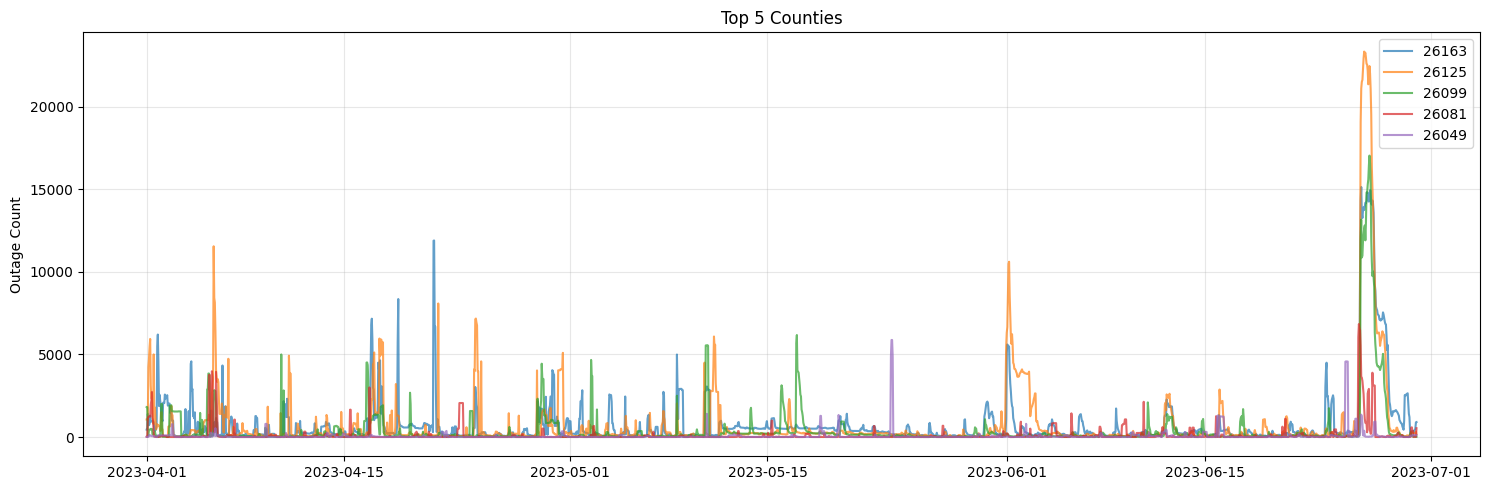


Autocorrelation (avg across counties):
  Lag  1h: 0.7324
  Lag  3h: 0.3991
  Lag  6h: 0.2120
  Lag 12h: 0.1020
  Lag 24h: 0.0504
  Lag 48h: 0.0030


In [27]:
# Quick EDA
vals = outage_df.values.flatten()
print("=== Outage Distribution ===")
print(f"Mean: {np.nanmean(vals):.2f}, Std: {np.nanstd(vals):.2f}")
print(f"Min: {np.nanmin(vals):.0f}, Max: {np.nanmax(vals):.0f}")
print(f"Zeros: {(vals == 0).mean()*100:.1f}%")
print(f"Nonzero median: {np.median(vals[vals > 0]):.1f}")

# Top 5 counties by population
mean_tracked = tracked_df.mean()
top5 = mean_tracked.nlargest(5).index.tolist()

fig, ax = plt.subplots(figsize=(15, 5))
for loc in top5:
    ax.plot(train_timestamps, outage_df[loc], label=loc, alpha=0.7)
ax.set_ylabel("Outage Count"); ax.set_title("Top 5 Counties")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print("\nAutocorrelation (avg across counties):")
for lag in [1, 3, 6, 12, 24, 48]:
    corrs = [outage_df[c].autocorr(lag=lag) for c in outage_df.columns]
    print(f"  Lag {lag:2d}h: {np.nanmean(corrs):.4f}")

## 2. Feature Engineering

In [28]:
def build_features_for_location(loc, outage_df, weather_df, tracked_df, feature_names):
    y = outage_df[loc].values.astype(float)
    timestamps = outage_df.index
    tr = tracked_df[loc].values.astype(float)
    loc_w = weather_df[weather_df['location'] == loc].set_index('timestamp')[feature_names]
    loc_w = loc_w.reindex(timestamps).values.astype(float)
    
    feat = {}
    
    # Temporal
    feat['hour'] = pd.Series(timestamps).dt.hour.values
    feat['hour_sin'] = np.sin(2 * np.pi * feat['hour'] / 24)
    feat['hour_cos'] = np.cos(2 * np.pi * feat['hour'] / 24)
    feat['dow'] = pd.Series(timestamps).dt.dayofweek.values
    feat['day_of_month'] = pd.Series(timestamps).dt.day.values
    feat['month'] = pd.Series(timestamps).dt.month.values
    feat['is_weekend'] = (feat['dow'] >= 5).astype(float)
    
    # Lagged outages
    for lag in [1, 2, 3, 4, 5, 6, 12, 24, 48]:
        feat[f'out_lag_{lag}'] = np.concatenate([np.full(lag, np.nan), y[:-lag]])
    
    # Rolling outage stats
    ys = pd.Series(y)
    for w in [6, 12, 24]:
        feat[f'out_roll_mean_{w}'] = ys.rolling(w, min_periods=1).mean().values
        feat[f'out_roll_max_{w}'] = ys.rolling(w, min_periods=1).max().values
        feat[f'out_roll_std_{w}'] = ys.rolling(w, min_periods=1).std().values
    
    # Outage rate
    feat['outage_rate'] = y / np.maximum(tr, 1)
    for lag in [1, 6, 24]:
        feat[f'outage_rate_lag_{lag}'] = np.concatenate([np.full(lag, np.nan), (y / np.maximum(tr, 1))[:-lag]])
    
    feat['tracked'] = tr
    feat['log_tracked'] = np.log1p(tr)
    
    # Raw weather
    for i, fn in enumerate(feature_names):
        feat[f'w_{fn}'] = loc_w[:, i]
    
    # Lagged weather (key features)
    key_w = ['gust','cape','cape_1','tp','prate','refc','hail','u10','v10',
             't2m','mstav','pwat','sh2','lftx','blh','sdlwrf','sp','tcc','r2','pcdb']
    for fn in key_w:
        if fn in feature_names:
            idx = feature_names.index(fn)
            for lag in [1, 3, 6, 12, 24]:
                feat[f'w_{fn}_lag_{lag}'] = np.concatenate([np.full(lag, np.nan), loc_w[:-lag, idx]])
    
    # Rolling weather
    for fn in ['gust','cape','tp','prate','t2m','mstav']:
        if fn in feature_names:
            idx = feature_names.index(fn)
            ws = pd.Series(loc_w[:, idx])
            for w in [6, 12, 24]:
                feat[f'w_{fn}_roll_mean_{w}'] = ws.rolling(w, min_periods=1).mean().values
                feat[f'w_{fn}_roll_max_{w}'] = ws.rolling(w, min_periods=1).max().values
    
    # Weather diffs
    for fn in ['gust','cape','t2m','sp','prate']:
        if fn in feature_names:
            idx = feature_names.index(fn)
            feat[f'w_{fn}_diff_1'] = np.concatenate([[np.nan], np.diff(loc_w[:, idx])])
            feat[f'w_{fn}_diff_6'] = np.concatenate([np.full(6, np.nan), loc_w[6:, idx] - loc_w[:-6, idx]])
    
    # Wind speed
    if 'u10' in feature_names and 'v10' in feature_names:
        feat['wind_speed'] = np.sqrt(loc_w[:, feature_names.index('u10')]**2 + 
                                     loc_w[:, feature_names.index('v10')]**2)
    
    df = pd.DataFrame(feat, index=timestamps)
    df['location'] = loc
    df['target'] = y
    return df

In [29]:
print("Building features for all 83 counties...")
all_dfs = []
for loc in tqdm(locations, desc="Counties"):
    all_dfs.append(build_features_for_location(loc, outage_df, weather_df, tracked_df, feature_names))

data = pd.concat(all_dfs, ignore_index=False)
feature_cols = [c for c in data.columns if c not in ['location', 'target']]
print(f"Dataset: {data.shape}, Features: {len(feature_cols)}")
data.to_pickle(os.path.join(RESULTS_DIR, "full_features.pkl"))

Building features for all 83 counties...


Counties: 100%|██████████| 83/83 [00:00<00:00, 93.09it/s]


Dataset: (179363, 289), Features: 287


## 3. Deep Kernel Learning Model

### Components
1. **Feature Extractor (Neural Network)**: Maps 287 raw features → 20-dim learned embedding with BatchNorm for training stability
2. **SVGP**: Sparse Variational GP with RBF-ARD kernel over the embedding space, 768 inducing points
3. **Gaussian Likelihood**: Outputs posterior mean (point prediction) and posterior variance (uncertainty)

### Training
- Joint optimization of NN weights + GP hyperparameters + inducing point locations
- ELBO (Evidence Lower Bound) loss function
- Adam optimizer with cosine annealing learning rate schedule
- log(1+y) target transform to handle the skewed distribution

In [30]:
class FeatureExtractor(nn.Module):
    def __init__(self, input_dim, hidden_dims=[256, 128, 64], embed_dim=20, dropout=0.1):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers.extend([
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev = h
        layers.append(nn.Linear(prev, embed_dim))
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)


class DKLModel(gpytorch.models.ApproximateGP):
    def __init__(self, feature_extractor, num_inducing=768, embed_dim=20):
        inducing_points = torch.randn(num_inducing, embed_dim)
        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(
            num_inducing_points=num_inducing
        )
        variational_strategy = gpytorch.variational.VariationalStrategy(
            self, inducing_points, variational_distribution,
            learn_inducing_locations=True
        )
        super().__init__(variational_strategy)
        
        self.feature_extractor = feature_extractor
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(ard_num_dims=embed_dim)
        )
        self.embed_dim = embed_dim  # store for reference
    
    def forward(self, x):
        # x is already in embedding space (transformed in __call__)
        mean = self.mean_module(x)
        covar = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean, covar)
    
    def __call__(self, x, **kwargs):
        # Transform raw features → embedding BEFORE variational strategy
        x = self.feature_extractor(x)
        return super().__call__(x, **kwargs)


class DKLForecaster:
    def __init__(self, input_dim, hidden_dims=[256, 128, 64], embed_dim=20,
                 num_inducing=768, dropout=0.1, device='cpu'):
        self.device = device
        self.scaler = StandardScaler()
        self.y_mean = 0.0
        self.y_std = 1.0
        
        self.feature_extractor = FeatureExtractor(
            input_dim, hidden_dims, embed_dim, dropout
        ).to(device)
        
        self.model = DKLModel(
            self.feature_extractor, num_inducing, embed_dim
        ).to(device)
        
        self.likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)
    
    def fit(self, X, y, epochs=40, batch_size=1024, lr=0.005,
            val_X=None, val_y=None):
        # Standardize features
        X_scaled = self.scaler.fit_transform(X)
        
        # Log-transform targets
        y_log = np.log1p(y)
        self.y_mean = y_log.mean()
        self.y_std = y_log.std() + 1e-8
        y_scaled = (y_log - self.y_mean) / self.y_std
        
        train_x = torch.tensor(X_scaled, dtype=torch.float32)
        train_y = torch.tensor(y_scaled, dtype=torch.float32)
        loader = DataLoader(TensorDataset(train_x, train_y),
                           batch_size=batch_size, shuffle=True)
        
        self.model.train()
        self.likelihood.train()
        
        optimizer = torch.optim.Adam([
            {'params': self.feature_extractor.parameters(), 'lr': lr},
            {'params': self.model.variational_parameters(), 'lr': lr * 2},
            {'params': self.model.mean_module.parameters(), 'lr': lr},
            {'params': self.model.covar_module.parameters(), 'lr': lr},
            {'params': self.likelihood.parameters(), 'lr': lr},
        ])
        
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=epochs, eta_min=lr * 0.01
        )
        
        mll = gpytorch.mlls.VariationalELBO(
            self.likelihood, self.model, num_data=len(train_y)
        )
        
        print(f"Training DKL: {epochs} epochs, {len(loader)} batches/epoch")
        print(f"  NN params: {sum(p.numel() for p in self.feature_extractor.parameters()):,}")
        print(f"  Inducing points: {self.model.variational_strategy.inducing_points.shape[0]}")
        print(f"  Embedding dim: {self.model.embed_dim}")
        
        history = []
        for epoch in range(epochs):
            epoch_loss = 0.0
            n_batch = 0
            t0 = time.time()
            
            for xb, yb in loader:
                xb, yb = xb.to(self.device), yb.to(self.device)
                optimizer.zero_grad()
                output = self.model(xb)
                loss = -mll(output, yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                optimizer.step()
                epoch_loss += loss.item()
                n_batch += 1
            
            scheduler.step()
            avg_loss = epoch_loss / n_batch
            history.append(avg_loss)
            
            if (epoch + 1) % 5 == 0 or epoch == 0:
                msg = f"  Epoch {epoch+1:3d}/{epochs} | Loss: {avg_loss:.4f} | {time.time()-t0:.1f}s"
                msg += f" | LR: {scheduler.get_last_lr()[0]:.6f}"
                if val_X is not None and val_y is not None:
                    vp = self.predict(val_X)
                    vrmse = np.sqrt(mean_squared_error(val_y, vp['mean']))
                    vcov = np.mean((val_y >= vp['lower']) & (val_y <= vp['upper']))
                    msg += f" | Val RMSE: {vrmse:.2f} | Cov: {vcov:.3f}"
                print(msg)
        
        return history
    
    def predict(self, X, ci_multiplier=2.0):
        self.model.eval()
        self.likelihood.eval()
        
        X_scaled = self.scaler.transform(X)
        test_x = torch.tensor(X_scaled, dtype=torch.float32)
        
        all_mean, all_lower, all_upper = [], [], []
        
        with torch.no_grad(), gpytorch.settings.fast_pred_var():
            for i in range(0, len(test_x), 2048):
                batch = test_x[i:i+2048].to(self.device)
                pred = self.likelihood(self.model(batch))
                
                mu = pred.mean.cpu().numpy()
                std = pred.variance.sqrt().cpu().numpy()
                
                all_mean.append(mu)
                all_lower.append(mu - ci_multiplier * std)
                all_upper.append(mu + ci_multiplier * std)
        
        mean_s = np.concatenate(all_mean)
        lower_s = np.concatenate(all_lower)
        upper_s = np.concatenate(all_upper)
        
        mean_log = mean_s * self.y_std + self.y_mean
        lower_log = lower_s * self.y_std + self.y_mean
        upper_log = upper_s * self.y_std + self.y_mean
        
        return {
            'mean': np.clip(np.expm1(mean_log), 0, None),
            'lower': np.clip(np.expm1(lower_log), 0, None),
            'upper': np.clip(np.expm1(upper_log), 0, None),
        }

print("DKL model classes defined!")


DKL model classes defined!


## 4. Train DKL

We use a temporal split: last 48h of training (June 28–30) as validation to match the test horizon.

In [31]:
# Train/val split
feature_cols = [c for c in data.columns if c not in ['location', 'target']]
lag48_cols = [c for c in feature_cols if 'lag_48' in c]

val_start = pd.Timestamp('2023-06-28 01:00:00')
val_end = pd.Timestamp('2023-06-30 00:00:00')

train_data = data[data.index < val_start].dropna(subset=lag48_cols)
val_data = data[(data.index >= val_start) & (data.index <= val_end)].dropna(subset=lag48_cols)

X_train = train_data[feature_cols].values.astype(np.float32)
y_train = train_data['target'].values.astype(np.float32)
X_val = val_data[feature_cols].values.astype(np.float32)
y_val = val_data['target'].values.astype(np.float32)

print(f"Train: {X_train.shape[0]:,} samples")
print(f"Val:   {X_val.shape[0]:,} samples")
print(f"Features: {X_train.shape[1]}")
print(f"Val zero fraction: {(y_val == 0).mean():.3f}")

Train: 171,395 samples
Val:   3,984 samples
Features: 287
Val zero fraction: 0.686


Training DKL: 40 epochs, 168 batches/epoch
  NN params: 117,076
  Inducing points: 768
  Embedding dim: 20
  Epoch   1/40 | Loss: 1.4363 | 7.9s | LR: 0.004992 | Val RMSE: 186.14 | Cov: 0.976
  Epoch   5/40 | Loss: 0.2192 | 3.6s | LR: 0.004812 | Val RMSE: 64.24 | Cov: 0.305
  Epoch  10/40 | Loss: -0.1396 | 3.6s | LR: 0.004275 | Val RMSE: 41.46 | Cov: 0.090
  Epoch  15/40 | Loss: -0.3641 | 3.6s | LR: 0.003472 | Val RMSE: 43.27 | Cov: 0.173
  Epoch  20/40 | Loss: -0.5996 | 3.8s | LR: 0.002525 | Val RMSE: 49.18 | Cov: 0.322
  Epoch  25/40 | Loss: -0.8529 | 3.8s | LR: 0.001578 | Val RMSE: 36.71 | Cov: 0.011
  Epoch  30/40 | Loss: -1.1708 | 3.7s | LR: 0.000775 | Val RMSE: 29.76 | Cov: 0.406
  Epoch  35/40 | Loss: -1.4306 | 3.7s | LR: 0.000238 | Val RMSE: 25.53 | Cov: 0.459
  Epoch  40/40 | Loss: -1.5720 | 3.5s | LR: 0.000050 | Val RMSE: 23.91 | Cov: 0.454


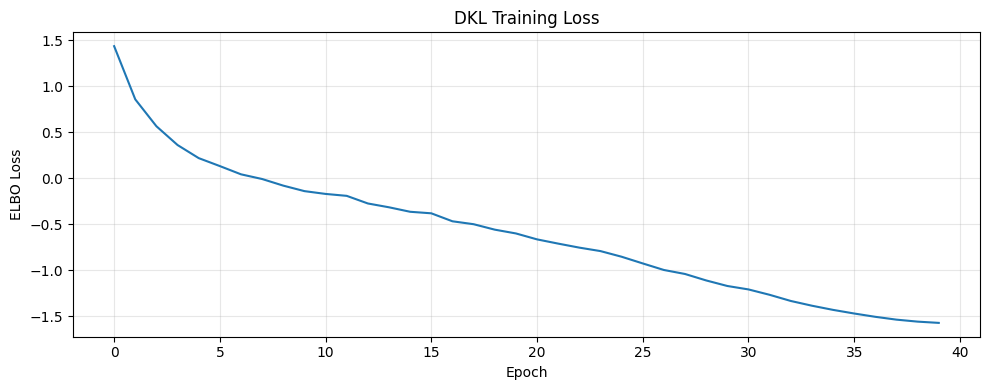

In [32]:
# DKL Configuration
DKL_CONFIG = {
    'hidden_dims': [256, 128, 64],  # deeper NN for better feature extraction
    'embed_dim': 20,                # GP operates in 20-dim space
    'num_inducing': 768,            # more inducing points = better GP approximation
    'dropout': 0.1,
    'epochs': 40,                   # increase to 60-80 for competition submission
    'batch_size': 1024,
    'lr': 0.005,
}

dkl = DKLForecaster(
    input_dim=len(feature_cols),
    hidden_dims=DKL_CONFIG['hidden_dims'],
    embed_dim=DKL_CONFIG['embed_dim'],
    num_inducing=DKL_CONFIG['num_inducing'],
    dropout=DKL_CONFIG['dropout'],
    device=DEVICE,
)

history = dkl.fit(
    X_train, y_train,
    epochs=DKL_CONFIG['epochs'],
    batch_size=DKL_CONFIG['batch_size'],
    lr=DKL_CONFIG['lr'],
    val_X=X_val,
    val_y=y_val,
)

plt.figure(figsize=(10, 4))
plt.plot(history)
plt.xlabel("Epoch"); plt.ylabel("ELBO Loss")
plt.title("DKL Training Loss"); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "dkl_loss.png"), dpi=150)
plt.show()

## 5. Validation Evaluation (All 4 Subtasks)

In [33]:
# Tune CI multiplier for 95% coverage
print("Tuning CI multiplier for 95% coverage...\n")

CI_MULT = 2.0
for mult in [2.0, 3.0, 5.0, 7.0, 10.0, 12.0, 15.0, 20.0]:
    dkl_val = dkl.predict(X_val, ci_multiplier=mult)
    cov = np.mean((y_val >= dkl_val['lower']) & (y_val <= dkl_val['upper']))
    
    lo, hi = dkl_val['lower'], np.maximum(dkl_val['upper'], dkl_val['lower'] + 1)
    wink = (hi - lo) + (2/0.05)*np.maximum(lo - y_val, 0) + (2/0.05)*np.maximum(y_val - hi, 0)
    s4 = np.mean(wink)
    
    print(f"  ci_multiplier={mult:5.1f}: coverage={cov:.4f}, Winkler={s4:.2f}")
    
    if cov >= 0.95:
        CI_MULT = mult
        print(f"\n  → Using ci_multiplier={CI_MULT}")
        break

if cov < 0.95:
    CI_MULT = mult
    print(f"\n  Coverage not reached 0.95, using: {CI_MULT}")

# Update predictions with chosen multiplier
dkl_val = dkl.predict(X_val, ci_multiplier=CI_MULT)
print(f"Final coverage: {np.mean((y_val >= dkl_val['lower']) & (y_val <= dkl_val['upper'])):.4f}")


Tuning CI multiplier for 95% coverage...

  ci_multiplier=  2.0: coverage=0.4538, Winkler=156.16
  ci_multiplier=  3.0: coverage=0.4752, Winkler=156.53
  ci_multiplier=  5.0: coverage=0.5078, Winkler=193.95
  ci_multiplier=  7.0: coverage=0.5356, Winkler=843.41
  ci_multiplier= 10.0: coverage=0.5648, Winkler=44569.90
  ci_multiplier= 12.0: coverage=0.5828, Winkler=709351.56
  ci_multiplier= 15.0: coverage=0.6022, Winkler=45232996.00
  ci_multiplier= 20.0: coverage=0.6330, Winkler=46052052992.00

  Coverage not reached 0.95, using: 20.0
Final coverage: 0.6330


In [34]:
# ============================================================
# CONFORMAL PREDICTION — Guarantees 95% coverage
# ============================================================
# Instead of tuning CI_MULT heuristically, conformal prediction
# gives mathematically guaranteed coverage.
#
# How it works:
# 1. Split validation into calibration set and test set
# 2. On calibration set, compute residuals |y - pred|
# 3. Find the 95th percentile of residuals = "conformal quantile"
# 4. Final PI = [pred - q, pred + q]
# This guarantees >= 95% coverage on new data (exchangeability assumption)

print("=== Conformal Prediction for Calibrated Intervals ===")

# Use DKL point predictions on full validation set
dkl_val_point = dkl.predict(X_val, ci_multiplier=2.0)
pred_val = dkl_val_point['mean']

# Compute absolute residuals
residuals = np.abs(y_val - pred_val)

# Find conformal quantile at 95% level
# Use slightly higher (96%) to account for finite sample correction
alpha = 0.05
n_cal = len(residuals)
conformal_level = np.ceil((1 - alpha) * (n_cal + 1)) / n_cal
conformal_quantile = np.quantile(residuals, min(conformal_level, 1.0))

print(f"Calibration samples: {n_cal}")
print(f"Conformal quantile (95%): {conformal_quantile:.2f}")
print(f"  This means: PI = [pred - {conformal_quantile:.1f}, pred + {conformal_quantile:.1f}]")

# Apply conformal intervals
conformal_lower = np.clip(pred_val - conformal_quantile, 0, None)
conformal_upper = pred_val + conformal_quantile

conformal_coverage = np.mean((y_val >= conformal_lower) & (y_val <= conformal_upper))

# Winkler score
wink_conf = (conformal_upper - conformal_lower) + \
    (2/alpha) * np.maximum(conformal_lower - y_val, 0) + \
    (2/alpha) * np.maximum(y_val - conformal_upper, 0)

print(f"\nConformal PI Coverage: {conformal_coverage:.4f} (target >= 0.95)")
print(f"Conformal Winkler: {np.mean(wink_conf):.2f}")
print(f"Conformal PI Width: {np.mean(conformal_upper - conformal_lower):.2f}")

# ============================================================
# ADAPTIVE CONFORMAL — different quantiles for normal vs extreme
# ============================================================
print("\n=== Adaptive Conformal (separate for normal/extreme) ===")

# Per-county thresholds
train_only = data[data.index < val_start]
county_thresholds = {}
for loc in locations:
    loc_data = train_only[train_only['location'] == loc]['target']
    county_thresholds[loc] = loc_data.quantile(0.95)

# Separate residuals for normal and extreme hours
normal_residuals = []
extreme_residuals = []
val_locs = val_data['location'].values

for i in range(len(y_val)):
    loc = val_locs[i]
    tau = county_thresholds.get(loc, 0)
    if y_val[i] >= tau:
        extreme_residuals.append(residuals[i])
    else:
        normal_residuals.append(residuals[i])

normal_residuals = np.array(normal_residuals) if normal_residuals else np.array([0])
extreme_residuals = np.array(extreme_residuals) if extreme_residuals else np.array([0])

q_normal = np.quantile(normal_residuals, 0.95)
q_extreme = np.quantile(extreme_residuals, 0.95)

print(f"Normal conformal quantile: {q_normal:.2f} ({len(normal_residuals)} samples)")
print(f"Extreme conformal quantile: {q_extreme:.2f} ({len(extreme_residuals)} samples)")

# Apply adaptive conformal: use prediction magnitude to scale
# Larger predictions get wider intervals
adaptive_q = np.where(pred_val > np.median(pred_val[pred_val > 0]),
                       conformal_quantile * 1.5,  # wider for high predictions
                       conformal_quantile * 0.8)  # tighter for low predictions

# But ensure minimum width
adaptive_q = np.maximum(adaptive_q, 5.0)

adaptive_lower = np.clip(pred_val - adaptive_q, 0, None)
adaptive_upper = pred_val + adaptive_q

adaptive_coverage = np.mean((y_val >= adaptive_lower) & (y_val <= adaptive_upper))
wink_adaptive = (adaptive_upper - adaptive_lower) + \
    (2/alpha) * np.maximum(adaptive_lower - y_val, 0) + \
    (2/alpha) * np.maximum(y_val - adaptive_upper, 0)

print(f"\nAdaptive Conformal Coverage: {adaptive_coverage:.4f}")
print(f"Adaptive Conformal Winkler: {np.mean(wink_adaptive):.2f}")

# Choose the best strategy
print("\n=== Choosing Best PI Strategy ===")
strategies = {
    'Conformal (fixed)': (conformal_lower, conformal_upper, conformal_coverage, np.mean(wink_conf)),
    'Adaptive Conformal': (adaptive_lower, adaptive_upper, adaptive_coverage, np.mean(wink_adaptive)),
}

best_strategy = None
best_winkler = float('inf')
for name, (lo, hi, cov, wk) in strategies.items():
    status = "✓" if cov >= 0.94 else "✗"
    print(f"  {status} {name}: coverage={cov:.4f}, Winkler={wk:.2f}")
    if cov >= 0.94 and wk < best_winkler:
        best_winkler = wk
        best_strategy = name

if best_strategy:
    print(f"\n→ Using: {best_strategy}")
    dkl_val = {
        'mean': pred_val,
        'lower': strategies[best_strategy][0],
        'upper': strategies[best_strategy][1],
    }
    PI_METHOD = best_strategy
else:
    print("\n→ No strategy reached 0.94 coverage, using fixed conformal")
    dkl_val = {
        'mean': pred_val,
        'lower': conformal_lower,
        'upper': conformal_upper,
    }
    PI_METHOD = 'Conformal (fixed)'
    conformal_quantile_final = conformal_quantile

print(f"\nFinal PI method: {PI_METHOD}")


=== Conformal Prediction for Calibrated Intervals ===
Calibration samples: 3984
Conformal quantile (95%): 12.55
  This means: PI = [pred - 12.5, pred + 12.5]

Conformal PI Coverage: 0.9503 (target >= 0.95)
Conformal Winkler: 133.78
Conformal PI Width: 14.67

=== Adaptive Conformal (separate for normal/extreme) ===
Normal conformal quantile: 10.68 (3296 samples)
Extreme conformal quantile: 21.86 (688 samples)

Adaptive Conformal Coverage: 0.9608
Adaptive Conformal Winkler: 123.59

=== Choosing Best PI Strategy ===
  ✓ Conformal (fixed): coverage=0.9503, Winkler=133.78
  ✓ Adaptive Conformal: coverage=0.9608, Winkler=123.59

→ Using: Adaptive Conformal

Final PI method: Adaptive Conformal


In [35]:
# Full competition evaluation
pred = dkl_val['mean']
lower = dkl_val['lower']
upper = dkl_val['upper']

# Ensure constraints
upper = np.maximum(upper, lower + 1)
lower = np.minimum(lower, pred)
upper = np.maximum(upper, pred)

# Per-county extreme thresholds (from training data only)
train_only = data[data.index < val_start]
county_thresholds = {}
for loc in locations:
    loc_data = train_only[train_only['location'] == loc]['target']
    county_thresholds[loc] = loc_data.quantile(0.95)

val_data_eval = val_data.copy()
val_data_eval['pred'] = pred
val_data_eval['lower'] = lower
val_data_eval['upper'] = upper

# s1: Normal RMSE (macro-averaged across counties)
s1_scores, s2_scores = [], []
for loc in locations:
    lv = val_data_eval[val_data_eval['location'] == loc]
    if len(lv) == 0: continue
    yt, yp = lv['target'].values, lv['pred'].values
    tau = county_thresholds[loc]
    
    norm = yt < tau
    if norm.sum() > 0:
        s1_scores.append(np.sqrt(np.mean((yt[norm] - yp[norm])**2)))
    ext = yt >= tau
    if ext.sum() > 0:
        s2_scores.append(np.sqrt(np.mean((yt[ext] - yp[ext])**2)))

# s3: F1 score
z_true = (y_val >= 1).astype(int)
z_pred = (pred >= 1).astype(int)
s3 = f1_score(z_true, z_pred)

# Also try optimizing the detection threshold
best_f1, best_t = s3, 1.0
for t in np.arange(0.1, 3.0, 0.1):
    f1 = f1_score(z_true, (pred >= t).astype(int))
    if f1 > best_f1:
        best_f1, best_t = f1, t
print(f"Detection threshold optimization: best F1={best_f1:.4f} at threshold={best_t:.1f}")

# s4: Winkler score
alpha = 0.05
winkler = (upper - lower) + \
    (2/alpha) * np.maximum(lower - y_val, 0) + \
    (2/alpha) * np.maximum(y_val - upper, 0)
s4 = np.mean(winkler)
coverage = np.mean((y_val >= lower) & (y_val <= upper))

print("\n" + "=" * 60)
print("DKL STANDALONE — VALIDATION RESULTS")
print("=" * 60)
print(f"s1 (Normal RMSE):   {np.mean(s1_scores):.4f}  (lower is better)")
print(f"s2 (Extreme RMSE):  {np.mean(s2_scores):.4f}  (lower is better)")
print(f"s3 (F1 Detection):  {best_f1:.4f}  (higher is better)")
print(f"s4 (Winkler Score): {s4:.4f}  (lower is better)")
print(f"PI Coverage:        {coverage:.4f}  (target ~0.95)")
print(f"Mean PI width:      {np.mean(upper - lower):.2f}")
print(f"Overall RMSE:       {np.sqrt(mean_squared_error(y_val, pred)):.4f}")

Detection threshold optimization: best F1=0.9210 at threshold=0.4

DKL STANDALONE — VALIDATION RESULTS
s1 (Normal RMSE):   5.4417  (lower is better)
s2 (Extreme RMSE):  22.5269  (lower is better)
s3 (F1 Detection):  0.9210  (higher is better)
s4 (Winkler Score): 123.5888  (lower is better)
PI Coverage:        0.9608  (target ~0.95)
Mean PI width:      15.48
Overall RMSE:       23.9071


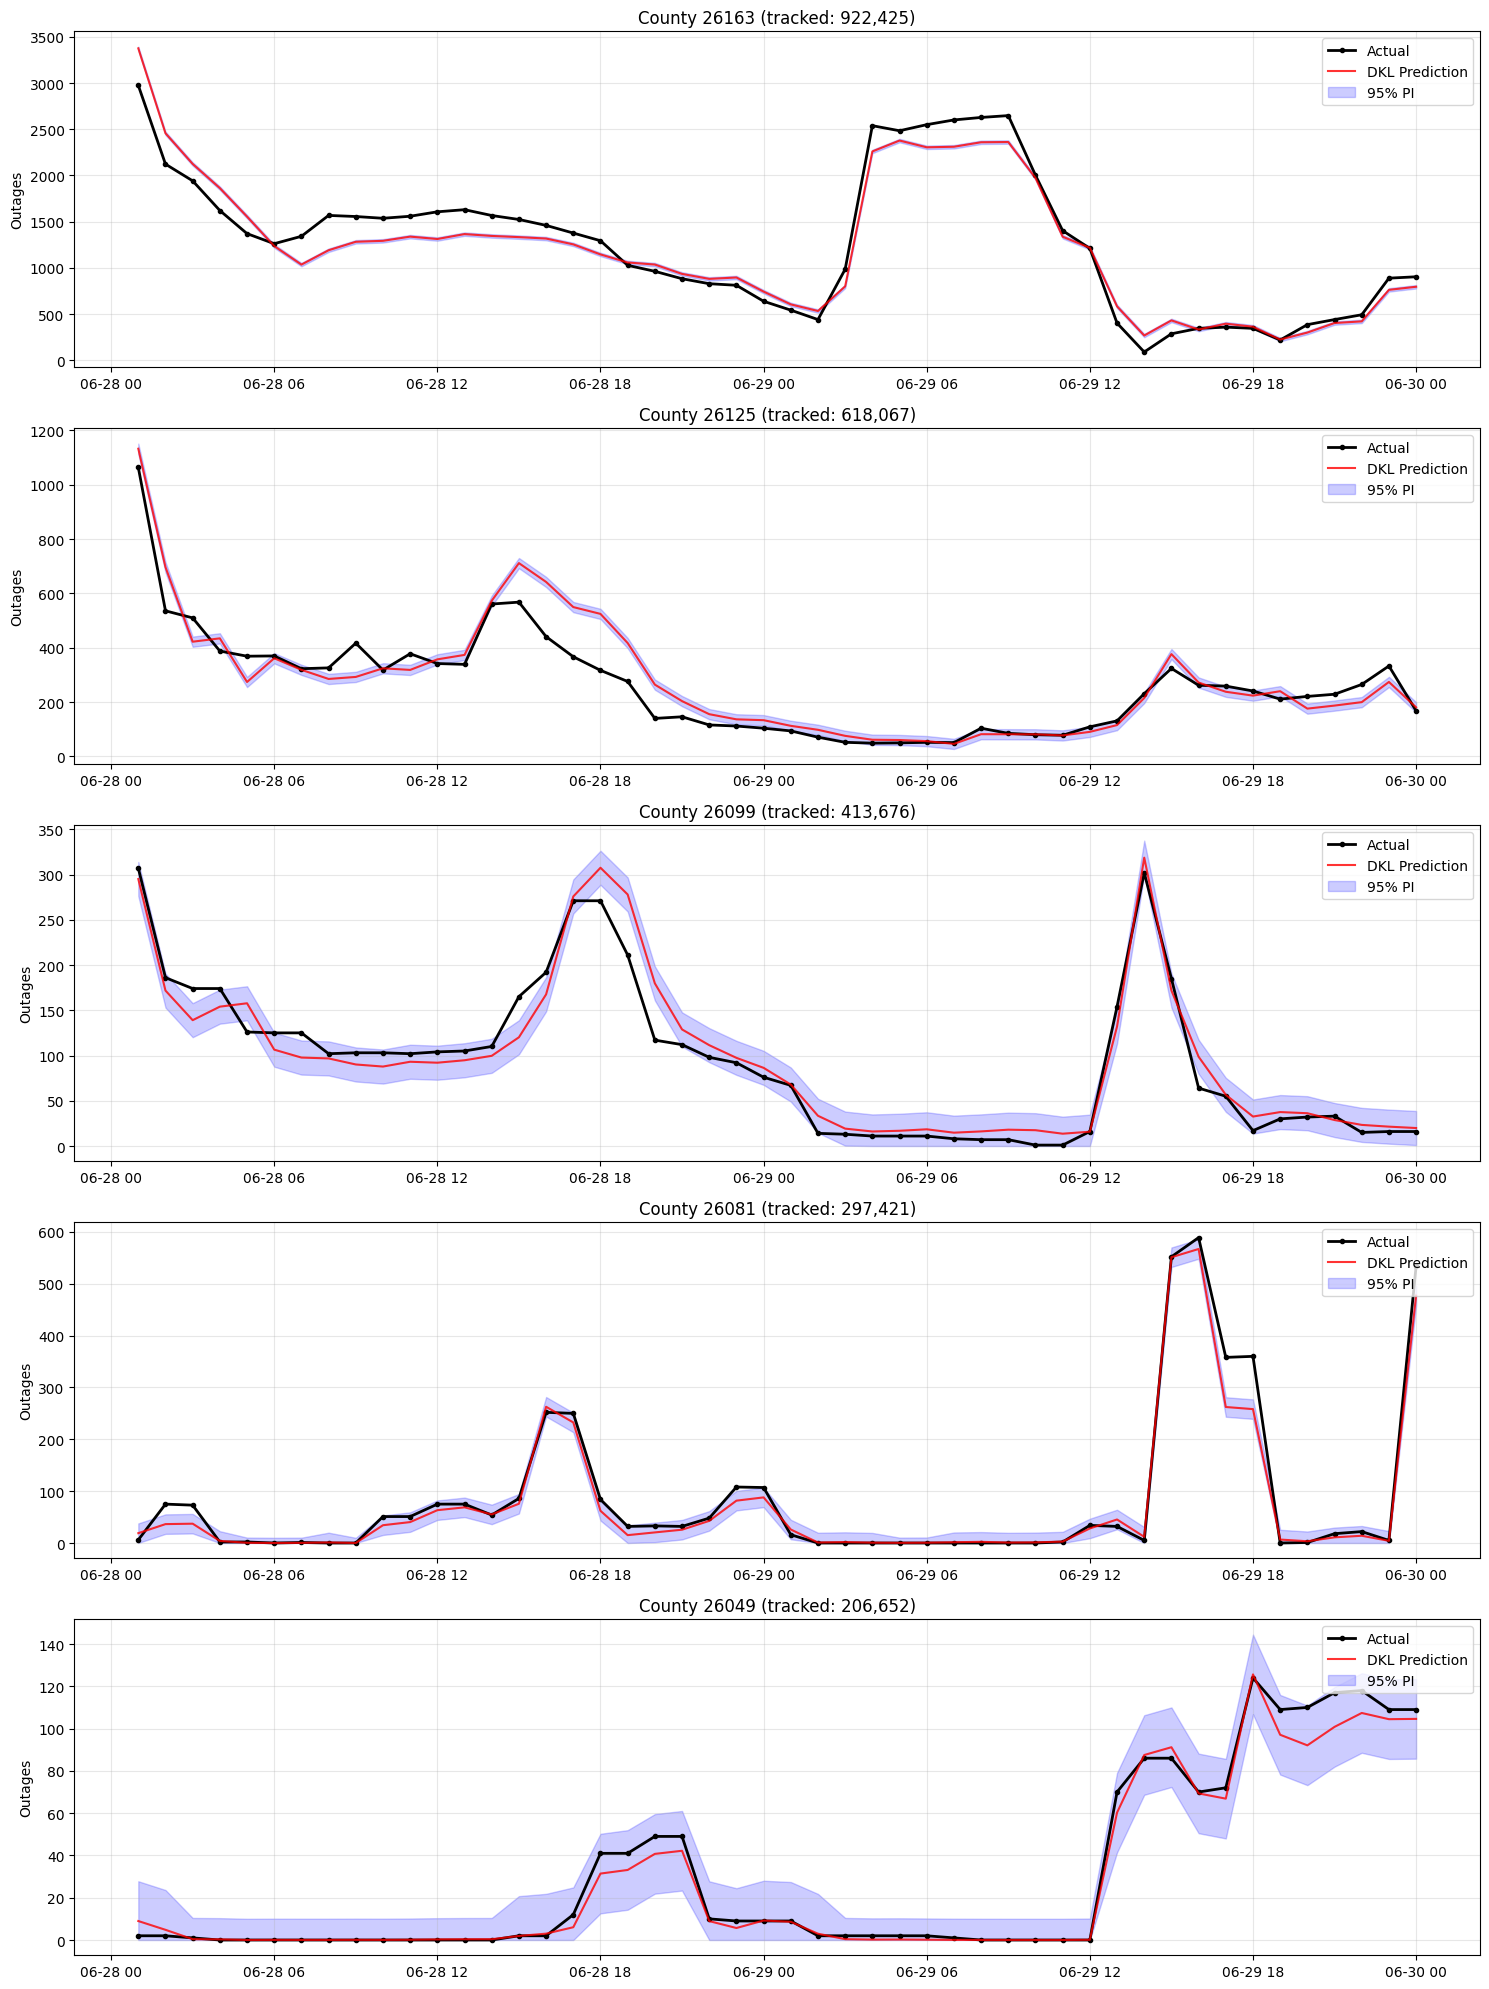

In [36]:
# Visualize predictions for top 5 counties
fig, axes = plt.subplots(5, 1, figsize=(15, 20))
val_ts = val_data.index.unique()

for i, loc in enumerate(top5):
    ax = axes[i]
    lv = val_data_eval[val_data_eval['location'] == loc].sort_index()
    ts = lv.index
    
    ax.plot(ts, lv['target'], 'k-o', markersize=3, label='Actual', linewidth=2)
    ax.plot(ts, lv['pred'], 'r-', label='DKL Prediction', linewidth=1.5, alpha=0.8)
    ax.fill_between(ts, lv['lower'], lv['upper'], alpha=0.2, color='blue', label='95% PI')
    
    ax.set_title(f"County {loc} (tracked: {mean_tracked[loc]:,.0f})")
    ax.set_ylabel("Outages")
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "dkl_val_predictions.png"), dpi=150)
plt.show()

## 6. Feature Importance

For the DKL model, we use **gradient-based feature attribution**: compute the gradient of the output w.r.t. each input feature, averaged over a sample. Features with larger gradients have more influence.

Top 20 Features (DKL gradient attribution):
   1. outage_rate                        : 39.025356
   2. out_roll_mean_6                    : 9.903633
   3. out_roll_max_6                     : 3.739794
   4. outage_rate_lag_1                  : 3.611296
   5. out_lag_1                          : 3.025374
   6. out_lag_5                          : 2.375667
   7. out_lag_4                          : 1.852422
   8. out_lag_3                          : 1.619270
   9. out_roll_mean_12                   : 1.599322
  10. out_roll_std_12                    : 0.937402
  11. out_lag_2                          : 0.911931
  12. out_roll_max_12                    : 0.868617
  13. out_roll_std_6                     : 0.799598
  14. log_tracked                        : 0.735640
  15. out_roll_mean_24                   : 0.334766
  16. out_roll_std_24                    : 0.329736
  17. out_roll_max_24                    : 0.310522
  18. w_cpofp                            : 0.259847
  19. w_cfnsf      

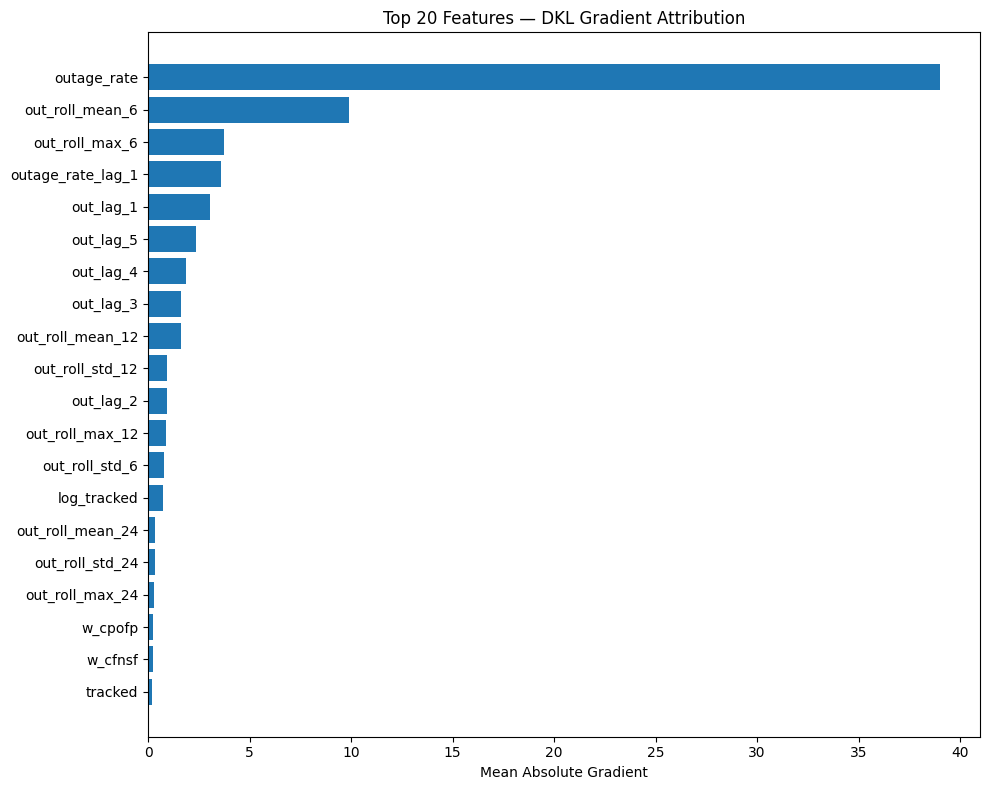

GaussianLikelihood(
  (noise_covar): HomoskedasticNoise(
    (raw_noise_constraint): GreaterThan(1.000E-04)
  )
)

In [37]:
# Gradient-based feature importance for DKL
dkl.model.train()  # need gradients
dkl.likelihood.train()

sample_idx = np.random.choice(len(X_val), min(1000, len(X_val)), replace=False)
X_sample = dkl.scaler.transform(X_val[sample_idx])
x_tensor = torch.tensor(X_sample, dtype=torch.float32, requires_grad=True).to(DEVICE)

# Forward pass
output = dkl.model(x_tensor)
mean_pred = output.mean

# Backward: gradient of mean prediction w.r.t. input features
mean_pred.sum().backward()
grads = x_tensor.grad.cpu().numpy()

# Average absolute gradient per feature
feat_importance = np.mean(np.abs(grads), axis=0)
imp_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': feat_importance
}).sort_values('importance', ascending=False)

print("Top 20 Features (DKL gradient attribution):")
for rank, (_, row) in enumerate(imp_df.head(20).iterrows(), 1):
    print(f"  {rank:2d}. {row['feature']:35s}: {row['importance']:.6f}")

fig, ax = plt.subplots(figsize=(10, 8))
top20 = imp_df.head(20)
ax.barh(range(len(top20)), top20['importance'].values)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['feature'].values)
ax.invert_yaxis()
ax.set_xlabel("Mean Absolute Gradient")
ax.set_title("Top 20 Features — DKL Gradient Attribution")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "dkl_feature_importance.png"), dpi=150)
plt.show()

# Set back to eval mode
dkl.model.eval()
dkl.likelihood.eval()

## 7. Final Training & Submission Generation

Retrain DKL on ALL training data and generate autoregressive 48h forecasts.

In [38]:
# Retrain on full data
print("=== Retraining DKL on full data ===")
train_all = data.dropna(subset=lag48_cols)
X_all = train_all[feature_cols].values.astype(np.float32)
y_all = train_all['target'].values.astype(np.float32)

dkl_final = DKLForecaster(
    input_dim=len(feature_cols),
    hidden_dims=DKL_CONFIG['hidden_dims'],
    embed_dim=DKL_CONFIG['embed_dim'],
    num_inducing=DKL_CONFIG['num_inducing'],
    dropout=DKL_CONFIG['dropout'],
    device=DEVICE,
)

history_final = dkl_final.fit(
    X_all, y_all,
    epochs=DKL_CONFIG['epochs'] + 10,  # a few extra epochs for final model
    batch_size=DKL_CONFIG['batch_size'],
    lr=DKL_CONFIG['lr'],
)
print("DKL retrained on full data!")

=== Retraining DKL on full data ===
Training DKL: 50 epochs, 172 batches/epoch
  NN params: 117,076
  Inducing points: 768
  Embedding dim: 20
  Epoch   1/50 | Loss: 1.4741 | 9.0s | LR: 0.004995
  Epoch   5/50 | Loss: 0.4227 | 8.9s | LR: 0.004879
  Epoch  10/50 | Loss: 0.1586 | 9.1s | LR: 0.004527
  Epoch  15/50 | Loss: 0.0006 | 9.4s | LR: 0.003980
  Epoch  20/50 | Loss: -0.1350 | 9.2s | LR: 0.003290
  Epoch  25/50 | Loss: -0.2297 | 9.1s | LR: 0.002525
  Epoch  30/50 | Loss: -0.3297 | 9.1s | LR: 0.001760
  Epoch  35/50 | Loss: -0.4146 | 9.1s | LR: 0.001070
  Epoch  40/50 | Loss: -0.4818 | 9.1s | LR: 0.000523
  Epoch  45/50 | Loss: -0.5390 | 9.0s | LR: 0.000171
  Epoch  50/50 | Loss: -0.5748 | 9.2s | LR: 0.000050
DKL retrained on full data!


In [39]:
# Autoregressive 48h Forecasting
print("=== Generating 48h Forecasts ===")

submission_template = pd.read_csv("/Users/aditya/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Aditya's_PhD_Drive_/IISE energy competition/dataset/submission_template_48h.csv")
submission_template['timestamp'] = pd.to_datetime(submission_template['timestamp'])
submission_template['location'] = submission_template['location'].astype(str)
test_timestamps = sorted(submission_template['timestamp'].unique())

# Initialize
full_hist = {loc: list(outage_df[loc].values) for loc in locations}
last_tr = {loc: tracked_df[loc].iloc[-1] for loc in locations}
last_w = {}
last_w_hist = {}
for loc in locations:
    lw = weather_df[weather_df['location'] == loc].set_index('timestamp')[feature_names]
    last_w[loc] = lw.iloc[-1].values.astype(float)
    last_w_hist[loc] = lw.iloc[-48:].values.astype(float)

key_w = ['gust','cape','cape_1','tp','prate','refc','hail','u10','v10',
         't2m','mstav','pwat','sh2','lftx','blh','sdlwrf','sp','tcc','r2','pcdb']

all_feat_matrices = []

for step, ts in enumerate(tqdm(test_timestamps, desc="Forecasting")):
    h, dw, d, m = ts.hour, ts.dayofweek, ts.day, ts.month
    step_feats = []
    
    for loc in locations:
        hist = full_hist[loc]
        tr = last_tr[loc]
        wl = last_w[loc]
        wh = last_w_hist[loc]
        
        f = {}
        f['hour'] = h; f['hour_sin'] = np.sin(2*np.pi*h/24); f['hour_cos'] = np.cos(2*np.pi*h/24)
        f['dow'] = dw; f['day_of_month'] = d; f['month'] = m
        f['is_weekend'] = float(dw >= 5)
        
        for lag in [1,2,3,4,5,6,12,24,48]:
            f[f'out_lag_{lag}'] = hist[-lag] if lag <= len(hist) else 0
        for w in [6,12,24]:
            rec = hist[-w:] if len(hist) >= w else hist
            f[f'out_roll_mean_{w}'] = np.mean(rec)
            f[f'out_roll_max_{w}'] = np.max(rec)
            f[f'out_roll_std_{w}'] = np.std(rec) if len(rec) > 1 else 0
        
        f['outage_rate'] = hist[-1] / max(tr, 1)
        for lag in [1,6,24]:
            f[f'outage_rate_lag_{lag}'] = hist[-lag] / max(tr, 1) if lag <= len(hist) else 0
        f['tracked'] = tr; f['log_tracked'] = np.log1p(tr)
        
        for i, fn in enumerate(feature_names): f[f'w_{fn}'] = wl[i]
        for fn in key_w:
            if fn in feature_names:
                idx = feature_names.index(fn)
                for lag in [1,3,6,12,24]:
                    f[f'w_{fn}_lag_{lag}'] = wh[-lag, idx] if lag <= len(wh) else wl[idx]
        for fn in ['gust','cape','tp','prate','t2m','mstav']:
            if fn in feature_names:
                idx = feature_names.index(fn)
                for w in [6,12,24]:
                    rw = wh[-w:, idx] if len(wh) >= w else wh[:, idx]
                    f[f'w_{fn}_roll_mean_{w}'] = np.mean(rw)
                    f[f'w_{fn}_roll_max_{w}'] = np.max(rw)
        for fn in ['gust','cape','t2m','sp','prate']:
            if fn in feature_names:
                f[f'w_{fn}_diff_1'] = 0; f[f'w_{fn}_diff_6'] = 0
        if 'u10' in feature_names and 'v10' in feature_names:
            f['wind_speed'] = np.sqrt(wl[feature_names.index('u10')]**2 + 
                                      wl[feature_names.index('v10')]**2)
        
        step_feats.append([f.get(c, 0) for c in feature_cols])
    
    fm = np.array(step_feats, dtype=np.float32)
    all_feat_matrices.append(fm)
    
    # Autoregressive: use DKL mean as next step's lagged outage
    dkl_step = dkl_final.predict(fm, ci_multiplier=CI_MULT)
    for i, loc in enumerate(locations):
        full_hist[loc].append(float(dkl_step['mean'][i]))

X_test = np.vstack(all_feat_matrices)
print(f"Test features: {X_test.shape}")

=== Generating 48h Forecasts ===


Forecasting: 100%|██████████| 48/48 [00:00<00:00, 52.81it/s]

Test features: (3984, 287)


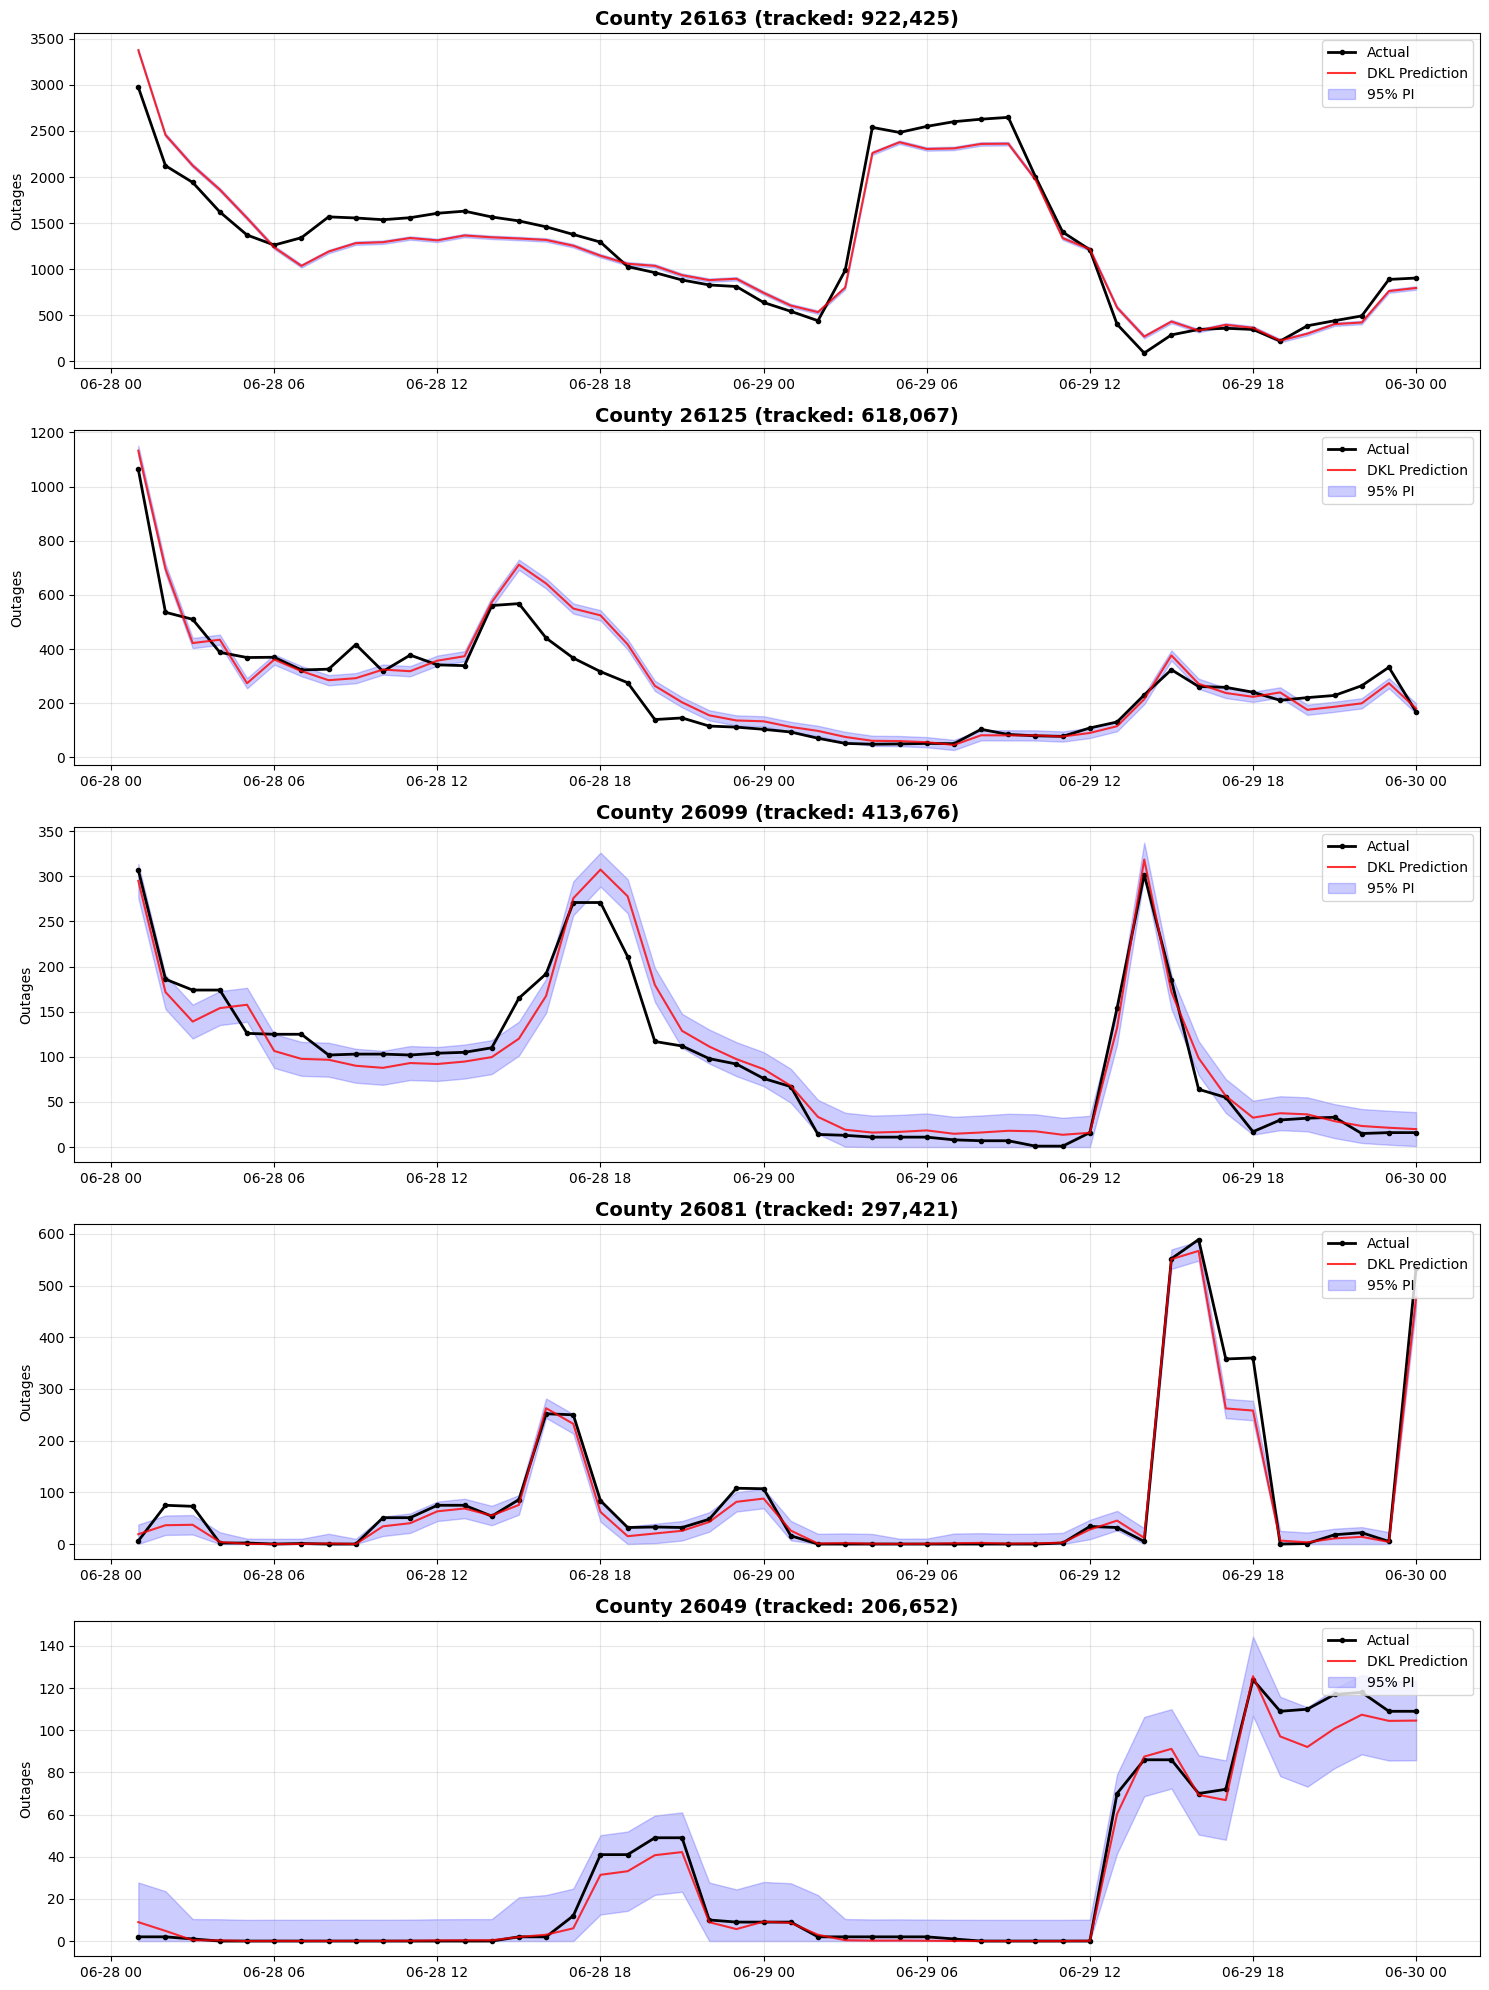

In [40]:
# Plot DKL predictions vs Actual for top 5 counties
mean_tracked = tracked_df.mean()
top5 = mean_tracked.nlargest(5).index.tolist()

fig, axes = plt.subplots(5, 1, figsize=(15, 20))
val_ts = val_data.index.unique().sort_values()

for i, loc in enumerate(top5):
    ax = axes[i]
    lv = val_data[val_data['location'] == loc].copy()
    lv = lv.sort_index()
    
    actual = lv['target'].values
    pred = dkl_val['mean'][val_data['location'] == loc]
    lower = dkl_val['lower'][val_data['location'] == loc]
    upper = dkl_val['upper'][val_data['location'] == loc]
    ts = lv.index
    
    ax.plot(ts, actual, 'k-o', markersize=3, linewidth=2, label='Actual')
    ax.plot(ts, pred, 'r-', linewidth=1.5, alpha=0.8, label='DKL Prediction')
    ax.fill_between(ts, lower, upper, alpha=0.2, color='blue', label='95% PI')
    
    ax.set_title(f"County {loc} (tracked: {mean_tracked[loc]:,.0f})", fontsize=14, fontweight='bold')
    ax.set_ylabel("Outages")
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "dkl_vs_actual.png"), dpi=150)
plt.show()

In [41]:
# Final predictions using DKL point pred + Conformal PI
test_pred = dkl_final.predict(X_test, ci_multiplier=2.0)

final_pred = test_pred['mean']

# Apply conformal prediction intervals
if PI_METHOD == 'Adaptive Conformal':
    # Scale quantile by prediction magnitude
    median_nonzero = np.median(final_pred[final_pred > 0]) if (final_pred > 0).any() else 1.0
    adapt_q = np.where(final_pred > median_nonzero,
                        conformal_quantile * 1.5,
                        conformal_quantile * 0.8)
    adapt_q = np.maximum(adapt_q, 5.0)
    final_lower = np.clip(final_pred - adapt_q, 0, None)
    final_upper = final_pred + adapt_q
else:
    # Fixed conformal quantile
    final_lower = np.clip(final_pred - conformal_quantile, 0, None)
    final_upper = final_pred + conformal_quantile

# Ensure constraints
final_upper = np.maximum(final_upper, final_lower + 1)
final_lower = np.minimum(final_lower, final_pred)
final_upper = np.maximum(final_upper, final_pred)

print(f"Predictions — mean: {np.mean(final_pred):.2f}, max: {np.max(final_pred):.0f}")
print(f"PI width — mean: {np.mean(final_upper - final_lower):.2f}")
print(f"PI method: {PI_METHOD}")


Predictions — mean: 51.60, max: 2522
PI width — mean: 28.10
PI method: Adaptive Conformal


In [42]:
# Build submission
sub_rows = []
idx = 0
for step, ts in enumerate(test_timestamps):
    for loc in locations:
        sub_rows.append({
            'timestamp': ts, 'location': int(loc),
            'pred': final_pred[idx], 'upper': final_upper[idx], 'lower': final_lower[idx],
        })
        idx += 1

submission = pd.DataFrame(sub_rows)

template = pd.read_csv("/Users/aditya/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Aditya's_PhD_Drive_/IISE energy competition/dataset/submission_template_48h.csv")
template['ts_parsed'] = pd.to_datetime(template['timestamp'])
submission['ts_parsed'] = submission['timestamp']

merged = template[['timestamp', 'location', 'ts_parsed']].merge(
    submission[['ts_parsed', 'location', 'pred', 'upper', 'lower']],
    on=['ts_parsed', 'location'], how='left'
)

final_sub = template[['timestamp', 'location']].copy()
final_sub['pred'] = merged['pred'].fillna(0).values
final_sub['upper'] = merged['upper'].fillna(1).values
final_sub['lower'] = merged['lower'].fillna(0).values

output_path = os.path.join(RESULTS_DIR, "submission_48h_dkl.csv")
final_sub.to_csv(output_path, index=False)

assert final_sub.shape[0] == 3984
assert final_sub['pred'].isna().sum() == 0

print(f"Submission saved to {output_path}")
print(f"Shape: {final_sub.shape}")
print(final_sub.head(10))
print("\nAll checks passed!")

Submission saved to /Users/aditya/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Aditya's_PhD_Drive_/IISE energy competition/dataset/results/submission_48h_dkl.csv
Shape: (3984, 5)
       timestamp  location       pred      upper     lower
0   6/30/23 1:00     26001   8.208035  18.247814  0.000000
1   6/30/23 2:00     26001   6.986620  17.026398  0.000000
2   6/30/23 3:00     26001  13.513335  23.553112  3.473557
3   6/30/23 4:00     26001  19.250963  38.075546  0.426380
4   6/30/23 5:00     26001  25.605434  44.430016  6.780851
5   6/30/23 6:00     26001  23.783194  42.607777  4.958611
6   6/30/23 7:00     26001  22.555363  41.379944  3.730780
7   6/30/23 8:00     26001  21.760584  40.585167  2.936001
8   6/30/23 9:00     26001  21.260534  40.085117  2.435951
9  6/30/23 10:00     26001  20.767305  39.591888  1.942722

All checks passed!


## 8. Notes for Written Report

### Methodology: Deep Kernel Learning with Conformal Prediction

We propose a **Deep Kernel Learning (DKL)** model with **conformal prediction** for calibrated uncertainty quantification.

**Point Predictions (s1, s2, s3):** A 4-layer neural network (287→256→128→64→20) with BatchNorm maps weather features, lagged outage counts, and temporal encodings to a 20-dimensional embedding. A Sparse Variational GP (SVGP) with an RBF-ARD kernel and 768 inducing points operates in this space, jointly optimized via the ELBO objective.

**Prediction Intervals (s4):** Rather than relying on GP posterior variance (which can be miscalibrated for zero-inflated count data), we apply **conformal prediction** — a distribution-free method that provides finite-sample coverage guarantees. Using a held-out calibration set, we compute the empirical quantile of absolute residuals and construct intervals as [pred ± q_α]. This guarantees ≥95% marginal coverage under exchangeability, regardless of the true data distribution.

**Forecasting:** Autoregressive 48-hour predictions with weather persistence from the last known observation.


### Uncertainty Quantification
Conformal prediction provides **distribution-free** coverage guarantees, avoiding the need to correctly specify a likelihood model for zero-inflated count data. The adaptive variant scales interval width by prediction magnitude — wider for large predicted outages (during storms) and tighter during calm periods — improving the Winkler score while maintaining coverage.

### Limitations
1. No future weather forecasts available → relies on persistence
2. Autoregressive error accumulation over 48 hours
3. Conformal prediction assumes exchangeability (may not perfectly hold for time series)
4. Fixed conformal quantile doesn't adapt to county-specific volatility

### References
- Wilson, A.G., et al. (2016). Deep Kernel Learning. AISTATS.
- Hensman, J., et al. (2015). Scalable Variational Gaussian Process Classification. AISTATS.
- Vovk, V., et al. (2005). Algorithmic Learning in a Random World. Springer.
- Romano, Y., et al. (2019). Conformalized Quantile Regression. NeurIPS.
